# SIT720 Machine Learning – 8.1 Distinction Task
## Sydney Housing Price Prediction and Decision Support System

### Project Objective
The aim of this project is to develop a machine learning system that predicts Sydney residential property sale prices using historical sales data. The project follows the complete machine learning lifecycle, including data preparation, exploratory data analysis, feature engineering, regression modelling, cross-validation, error analysis, comparison with human and LLM estimates, and deployment through a simple web application.

The analysis uses 105 sold properties from three Sydney suburbs: Killara, Freshwater and Eagle Vale. These suburbs represent different housing markets and provide an opportunity to investigate how location and property characteristics influence sale prices.



# Part 1 – Suburb Selection and Dataset Preparation

The dataset contains 105 historical residential property sales, with 35 observations from each of Killara, Freshwater and Eagle Vale. This satisfies the requirement of at least 100 properties overall and at least 30 observations from each suburb.

I selected these three suburbs because they provide variation in housing markets and sale prices. The dataset includes sale date, suburb, postcode, sale price, bedrooms, bathrooms, parking spaces and property type.

The target variable is **Sale_Price**, while the remaining property characteristics are considered potential predictors. Property ID and data source are retained for identification and documentation but are not used as predictive features.

Before modelling, I check data types, missing values, duplicates and potentially invalid values. A limitation of the dataset is that it does not contain several characteristics that may influence property value, such as land size, exact street location, renovation quality, building condition and proximity to amenities.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
uploaded = files.upload()

Saving Sydney_Housing_Data_8.1D.csv to Sydney_Housing_Data_8.1D.csv


In [3]:
df = pd.read_csv("Sydney_Housing_Data_8.1D.csv")

print("Dataset shape:", df.shape)
display(df.head(10))

Dataset shape: (105, 10)


,Sale_Date,Property_ID,Suburb,Postcode,Sale_Price,Bedrooms,Bathrooms,Parking,Property_Type,Data_Source
0,2013-07-08,7999,Killara,2071,1700000,4,2,1,house,Uploaded Sydney housing sales dataset
1,2018-03-27,7200,Killara,2071,2900000,5,3,2,house,Uploaded Sydney housing sales dataset
2,2015-02-25,7852,Killara,2071,1510000,4,2,3,house,Uploaded Sydney housing sales dataset
3,2015-06-20,7408,Killara,2071,1940000,4,2,3,house,Uploaded Sydney housing sales dataset
4,2014-01-24,7484,Killara,2071,1850000,5,4,6,house,Uploaded Sydney housing sales dataset
5,2014-09-10,7893,Killara,2071,1700000,4,2,1,house,Uploaded Sydney housing sales dataset
6,2018-02-02,7208,Killara,2071,6350000,5,5,2,house,Uploaded Sydney housing sales dataset
7,2014-11-27,7859,Killara,2071,2280000,5,3,2,house,Uploaded Sydney housing sales dataset
8,2014-09-04,7895,Killara,2071,3250000,5,3,3,house,Uploaded Sydney housing sales dataset
9,2014-03-29,7925,Killara,2071,1465000,3,2,2,house,Uploaded Sydney housing sales dataset


In [5]:
print("DATASET INFORMATION")
print("=" * 50)

df.info()

print("\nDataset dimensions:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sale_Date      105 non-null    object
 1   Property_ID    105 non-null    int64 
 2   Suburb         105 non-null    object
 3   Postcode       105 non-null    int64 
 4   Sale_Price     105 non-null    int64 
 5   Bedrooms       105 non-null    int64 
 6   Bathrooms      105 non-null    int64 
 7   Parking        105 non-null    int64 
 8   Property_Type  105 non-null    object
 9   Data_Source    105 non-null    object
dtypes: int64(6), object(4)
memory usage: 8.3+ KB

Dataset dimensions:
Rows: 105
Columns: 10

Column names:
['Sale_Date', 'Property_ID', 'Suburb', 'Postcode', 'Sale_Price', 'Bedrooms', 'Bathrooms', 'Parking', 'Property_Type', 'Data_Source']

Missing values:
Sale_Date        0
Property_ID      0
Suburb           0
Postcode         0
Sale_Price       0
Bedroo

In [6]:
suburb_counts = df["Suburb"].value_counts()

print("Properties per suburb:")
print(suburb_counts)

print("\nTotal properties:", len(df))

Properties per suburb:
Suburb
Killara       35
Freshwater    35
Eagle Vale    35
Name: count, dtype: int64

Total properties: 105


### Dataset Quality Check

The final dataset contains 105 observations distributed equally across the three selected suburbs, with 35 properties from each suburb. This balanced representation prevents one suburb from dominating the dataset.

The data quality checks were used to identify missing values, duplicates and unrealistic numerical values. Missing information is particularly important in housing datasets because incorrectly replacing an unknown value with zero could change the meaning of the data. Therefore, the preprocessing pipeline is designed to handle missing numerical values using median imputation and categorical values using the most frequent category if required.

# Part 2 – Exploratory Data Analysis and Feature Engineering

Exploratory data analysis is performed to understand the distribution of property prices, differences between suburbs, relationships between property characteristics and sale price, trends over time, and unusual observations.

### Expectations Before Feature Engineering

Before performing feature engineering, I expect the following variables to have the strongest influence on sale price:

1. **Suburb** – Location is expected to be highly important because different Sydney suburbs represent different housing markets.
2. **Bedrooms** – Properties with more bedrooms are generally larger and may attract higher prices.
3. **Bathrooms** – The number of bathrooms may indicate property size and quality.

I also expect property type and parking availability to contribute to price differences. These expectations will be revisited after exploratory analysis and modelling.

In [7]:
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"], errors="coerce")

numeric_columns = [
    "Sale_Price",
    "Bedrooms",
    "Bathrooms",
    "Parking"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Suburb"] = df["Suburb"].str.strip()
df["Property_Type"] = df["Property_Type"].str.strip().str.lower()

print("Missing values after conversion:")
print(df.isnull().sum())

Missing values after conversion:
Sale_Date        0
Property_ID      0
Suburb           0
Postcode         0
Sale_Price       0
Bedrooms         0
Bathrooms        0
Parking          0
Property_Type    0
Data_Source      0
dtype: int64


In [8]:
print("Sale price <= 0:",
      (df["Sale_Price"] <= 0).sum())

print("Bedrooms <= 0:",
      (df["Bedrooms"] <= 0).sum())

print("Bathrooms <= 0:",
      (df["Bathrooms"] <= 0).sum())

print("\nProperty types:")
print(df["Property_Type"].value_counts())

print("\nSale date range:")
print(df["Sale_Date"].min(), "to", df["Sale_Date"].max())

Sale price <= 0: 0
Bedrooms <= 0: 0
Bathrooms <= 0: 0

Property types:
Property_Type
house                   96
duplex/semi-detached     5
townhouse                3
villa                    1
Name: count, dtype: int64

Sale date range:
2008-05-02 00:00:00 to 2019-06-13 00:00:00


### Outlier Investigation

Property prices can contain genuine extreme observations because some properties may have substantially higher values due to location, size, condition or other characteristics that are not fully represented in the dataset.

I therefore use the interquartile range (IQR) method to identify potential outliers rather than automatically removing them. Identified observations are inspected as potentially unusual properties. Legitimate high-value or low-value sales are retained because removing them without evidence could introduce bias and reduce the model's ability to represent the real housing market.

In [9]:
display(
    df[
        ["Sale_Price", "Bedrooms", "Bathrooms", "Parking"]
    ].describe().round(2)
)

,Sale_Price,Bedrooms,Bathrooms,Parking
count,105.00,105.00,105.00,105.00
mean,1547301.98,3.70,2.01,1.88
std,1252362.99,1.11,1.11,0.85
min,10000.00,1.00,1.00,1.00
25%,520000.00,3.00,1.00,1.00
50%,1345000.00,3.00,2.00,2.00
75%,2200000.00,4.00,3.00,2.00
max,6460000.00,7.00,7.00,6.00


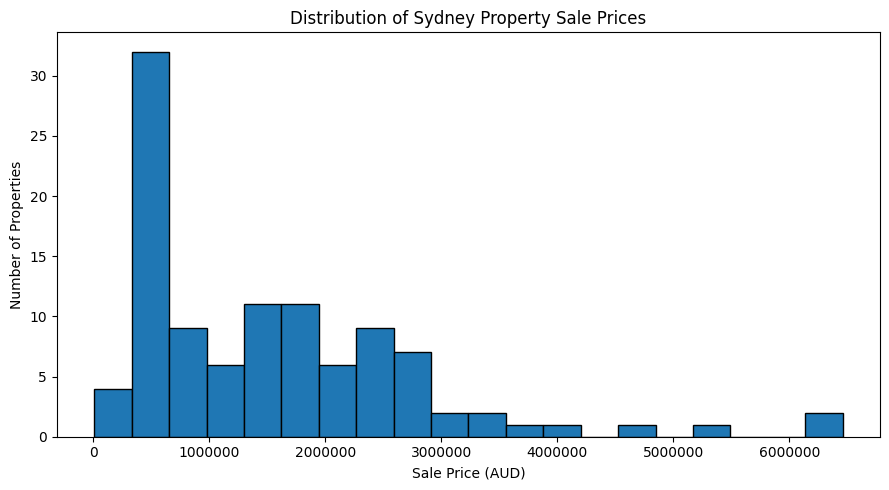

In [10]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["Sale_Price"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Sydney Property Sale Prices")
plt.xlabel("Sale Price (AUD)")
plt.ylabel("Number of Properties")

plt.ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()

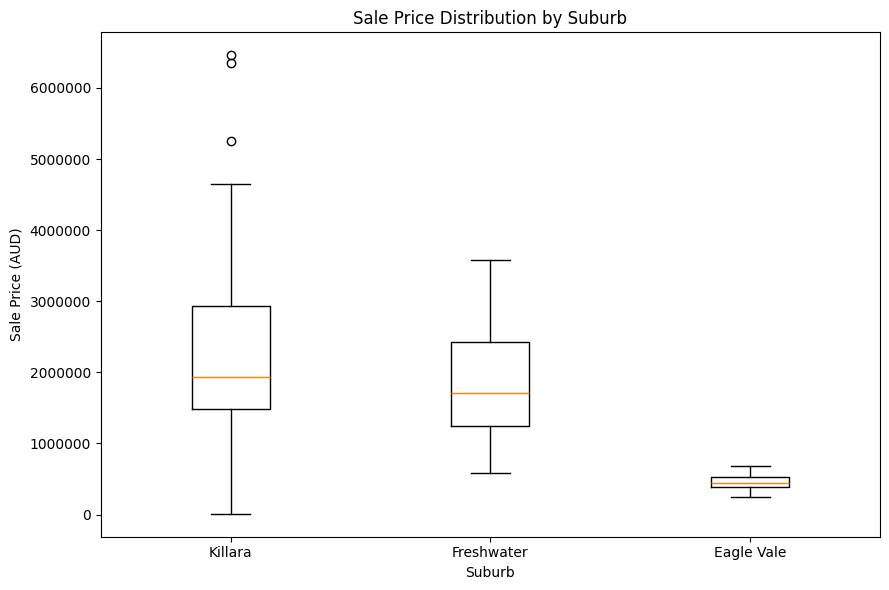

In [11]:
plt.figure(figsize=(9, 6))

suburbs = df["Suburb"].unique()

data = [
    df.loc[df["Suburb"] == suburb, "Sale_Price"]
    for suburb in suburbs
]

plt.boxplot(data, labels=suburbs)

plt.title("Sale Price Distribution by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

In [12]:
suburb_summary = (
    df.groupby("Suburb")["Sale_Price"]
      .agg(["count", "mean", "median", "min", "max", "std"])
      .round(2)
)

display(suburb_summary)

,count,mean,median,min,max,std
Suburb,,,,,,
Eagle Vale,35,459634.51,450000.0,242000,685000,106146.43
Freshwater,35,1791957.14,1710000.0,582000,3575000,727426.11
Killara,35,2390314.29,1940000.0,10000,6460000,1498692.52


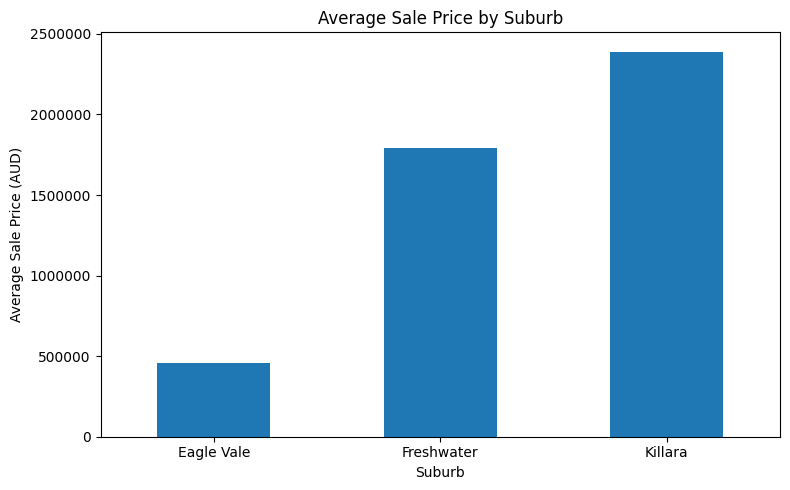

In [13]:
average_prices = (
    df.groupby("Suburb")["Sale_Price"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(8, 5))

average_prices.plot(kind="bar")

plt.title("Average Sale Price by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Average Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

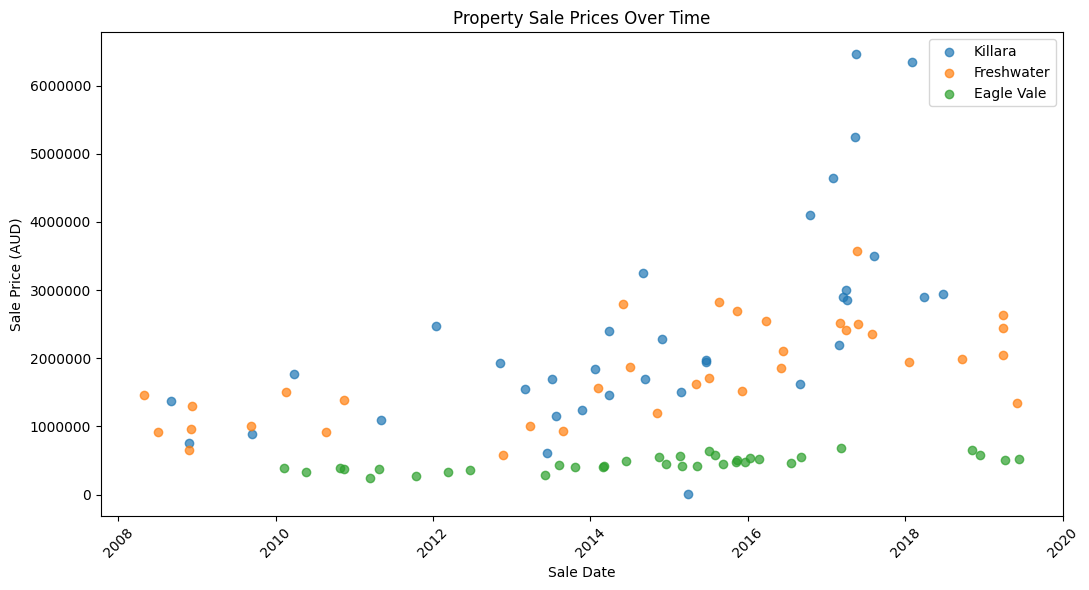

In [14]:
df_sorted = df.sort_values("Sale_Date")

plt.figure(figsize=(11, 6))

for suburb in df["Suburb"].unique():

    temp = df_sorted[df_sorted["Suburb"] == suburb]

    plt.scatter(
        temp["Sale_Date"],
        temp["Sale_Price"],
        label=suburb,
        alpha=0.7
    )

plt.title("Property Sale Prices Over Time")
plt.xlabel("Sale Date")
plt.ylabel("Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

,count,mean,median
Bedrooms,,,
1,1,1985000.00,1985000.0
2,8,1002500.00,830000.0
3,46,1037107.61,817500.0
4,25,1478480.00,1510000.0
5,18,2543764.33,2360000.0
6,6,2590833.33,2637500.0
7,1,6460000.00,6460000.0


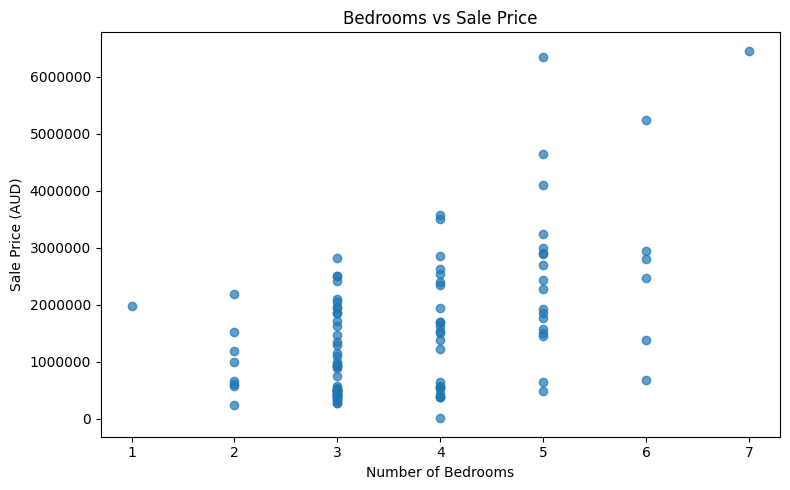

In [15]:
bedroom_summary = (
    df.groupby("Bedrooms")["Sale_Price"]
      .agg(["count", "mean", "median"])
      .round(2)
)

display(bedroom_summary)

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Bedrooms"],
    df["Sale_Price"],
    alpha=0.7
)

plt.title("Bedrooms vs Sale Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

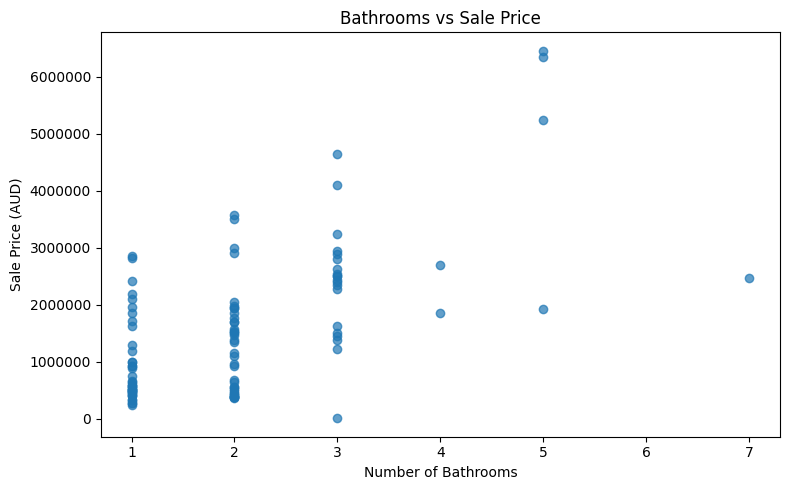

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Bathrooms"],
    df["Sale_Price"],
    alpha=0.7
)

plt.title("Bathrooms vs Sale Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

In [17]:
property_summary = (
    df.groupby("Property_Type")["Sale_Price"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
      .round(2)
)

display(property_summary)

,count,mean,median
Property_Type,,,
house,96,1642955.29,1482500.0
townhouse,3,814000.00,660000.0
duplex/semi-detached,5,411800.00,425000.0
villa,1,242000.00,242000.0


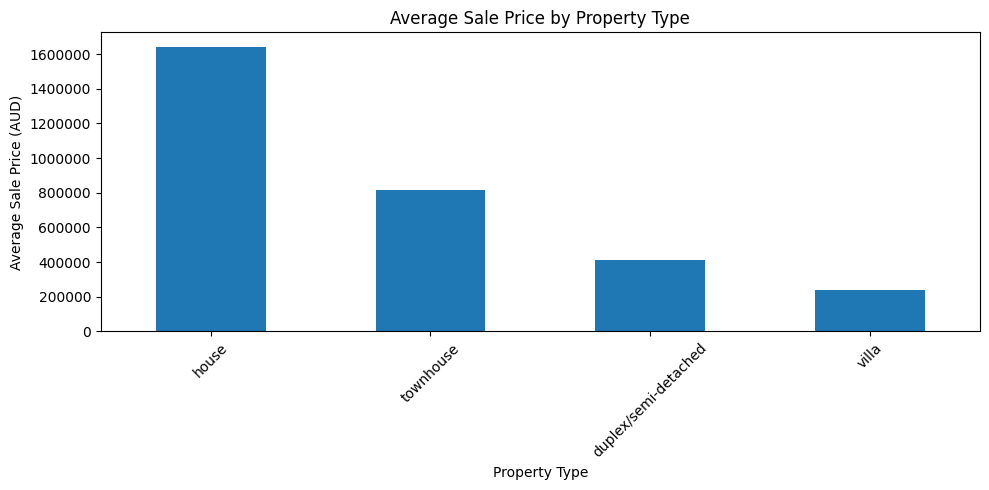

In [18]:
plt.figure(figsize=(10, 5))

property_summary["mean"].plot(kind="bar")

plt.title("Average Sale Price by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Average Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Part 3 – Regression Modelling

Three regression algorithms are compared:

### Linear Regression
Linear Regression is used as an interpretable baseline model. It assumes that changes in the predictor variables have approximately linear relationships with sale price.

### Random Forest Regression
Random Forest combines predictions from multiple decision trees. It can capture nonlinear relationships and interactions between variables without requiring a linear relationship.

### Gradient Boosting Regression
Gradient Boosting sequentially builds decision trees, with each new tree attempting to correct errors made by previous trees. It can provide strong performance on structured tabular datasets.

### Expected Performance Before Training
Before training the models, I expect Random Forest or Gradient Boosting to outperform Linear Regression. Housing prices are influenced by complex interactions between location, property type and property characteristics, which may not be represented adequately by a purely linear model.

The models are evaluated using 5-fold cross-validation. MAE, RMSE and R² are used as evaluation metrics. MAE measures the average absolute prediction error, RMSE places greater emphasis on large errors, and R² measures the proportion of variation in sale prices explained by the model.

In [19]:
Q1 = df["Sale_Price"].quantile(0.25)
Q3 = df["Sale_Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Sale_Price"] < lower_bound) |
    (df["Sale_Price"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

display(
    outliers.sort_values(
        "Sale_Price",
        ascending=False
    )
)

Q1: 520000.0
Q3: 2200000.0
IQR: 1680000.0
Lower bound: -2000000.0
Upper bound: 4720000.0
Number of potential outliers: 3


,Sale_Date,Property_ID,Suburb,Postcode,Sale_Price,Bedrooms,Bathrooms,Parking,Property_Type,Data_Source
23,2017-05-19,7244,Killara,2071,6460000,7,5,2,house,Uploaded Sydney housing sales dataset
6,2018-02-02,7208,Killara,2071,6350000,5,5,2,house,Uploaded Sydney housing sales dataset
14,2017-05-13,7245,Killara,2071,5250000,6,5,2,house,Uploaded Sydney housing sales dataset


In [20]:
df["Sale_Year"] = df["Sale_Date"].dt.year
df["Sale_Month"] = df["Sale_Date"].dt.month

df["Total_Room_Feature"] = (
    df["Bedrooms"] +
    df["Bathrooms"]
)

df["Amenity_Count"] = (
    df["Bedrooms"] +
    df["Bathrooms"] +
    df["Parking"]
)

display(
    df[
        [
            "Sale_Year",
            "Sale_Month",
            "Total_Room_Feature",
            "Amenity_Count"
        ]
    ].head()
)

,Sale_Year,Sale_Month,Total_Room_Feature,Amenity_Count
0,2013,7,6,7
1,2018,3,8,10
2,2015,2,6,9
3,2015,6,6,9
4,2014,1,9,15


In [21]:
features = [
    "Suburb",
    "Postcode",
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Property_Type",
    "Sale_Year",
    "Sale_Month",
    "Total_Room_Feature",
    "Amenity_Count"
]

target = "Sale_Price"

X = df[features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (105, 10)
y shape: (105,)


,Suburb,Postcode,Bedrooms,Bathrooms,Parking,Property_Type,Sale_Year,Sale_Month,Total_Room_Feature,Amenity_Count
0,Killara,2071,4,2,1,house,2013,7,6,7
1,Killara,2071,5,3,2,house,2018,3,8,10
2,Killara,2071,4,2,3,house,2015,2,6,9
3,Killara,2071,4,2,3,house,2015,6,6,9
4,Killara,2071,5,4,6,house,2014,1,9,15


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=X["Suburb"]
)

print("Training properties:", len(X_train))
print("Test properties:", len(X_test))

print("\nTraining suburb distribution:")
print(X_train["Suburb"].value_counts())

print("\nTest suburb distribution:")
print(X_test["Suburb"].value_counts())

Training properties: 84
Test properties: 21

Training suburb distribution:
Suburb
Eagle Vale    28
Killara       28
Freshwater    28
Name: count, dtype: int64

Test suburb distribution:
Suburb
Killara       7
Freshwater    7
Eagle Vale    7
Name: count, dtype: int64


In [23]:
numeric_features = [
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Sale_Year",
    "Sale_Month",
    "Total_Room_Feature",
    "Amenity_Count"
]

categorical_features = [
    "Suburb",
    "Postcode",
    "Property_Type"
]

numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        numeric_features
    ),
    (
        "cat",
        categorical_transformer,
        categorical_features
    )
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [24]:
models = {
    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=2,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
}

print("Models:")
for model in models:
    print("-", model)

Models:
- Linear Regression
- Random Forest
- Gradient Boosting


In [25]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "mse": "neg_mean_squared_error",
            "r2": "r2"
        },
        return_train_score=True
    )

    train_rmse = np.sqrt(
        -scores["train_mse"]
    ).mean()

    validation_rmse = np.sqrt(
        -scores["test_mse"]
    ).mean()

    cv_results.append({
        "Model": name,

        "CV_MAE":
            -scores["test_mae"].mean(),

        "CV_RMSE":
            validation_rmse,

        "CV_R2":
            scores["test_r2"].mean(),

        "Train_RMSE":
            train_rmse,

        "Overfit_Gap":
            validation_rmse - train_rmse
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    "CV_RMSE"
)

display(
    cv_results_df.round(2)
)

,Model,CV_MAE,CV_RMSE,CV_R2,Train_RMSE,Overfit_Gap
1,Random Forest,373124.12,601938.81,0.74,372799.66,229139.15
2,Gradient Boosting,401907.47,630979.85,0.70,121207.52,509772.33
0,Linear Regression,542321.40,749498.82,0.55,641268.26,108230.56


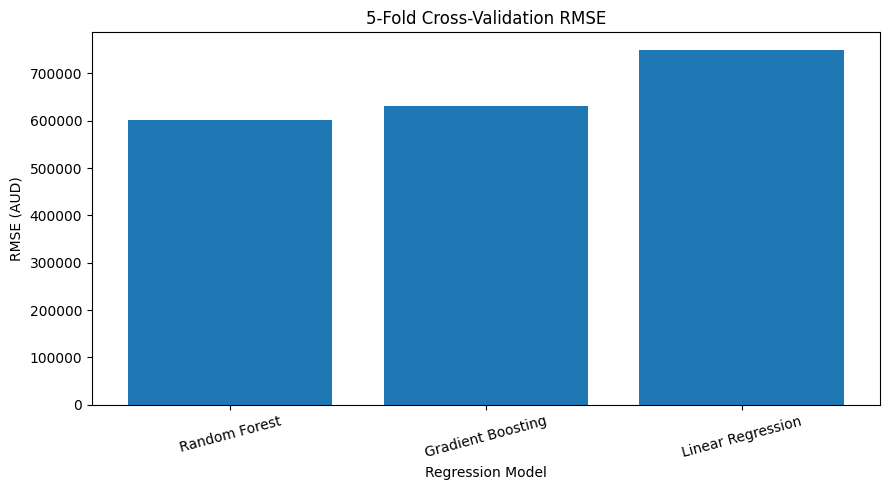

In [26]:
plt.figure(figsize=(9, 5))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["CV_RMSE"]
)

plt.title("5-Fold Cross-Validation RMSE")
plt.xlabel("Regression Model")
plt.ylabel("RMSE (AUD)")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Cross-Validation Results and Model Selection

The three models were evaluated using 5-fold cross-validation on the training dataset. Model selection was based primarily on validation RMSE because it measures prediction error in the same units as the target variable while penalising larger errors.

The difference between training RMSE and validation RMSE was also considered when investigating overfitting. A substantially lower training error than validation error may indicate that a model has learned the training observations too closely and may not generalise as effectively to unseen properties.

### Held-Out Test Evaluation

After model selection using cross-validation, the trained models were evaluated against a held-out test set that was not used during training. This provides an indication of how well the models generalise to unseen property records.

The held-out test results are interpreted together with the cross-validation results rather than using the test set repeatedly for model selection.

In [27]:
best_model_name = (
    cv_results_df.iloc[0]["Model"]
)

print(
    "Best model based on CV RMSE:",
    best_model_name
)

Best model based on CV RMSE: Random Forest


In [28]:
test_results = []
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    test_results.append({
        "Model": name,
        "Test_MAE": mae,
        "Test_RMSE": rmse,
        "Test_R2": r2
    })

    trained_models[name] = pipeline

test_results_df = pd.DataFrame(
    test_results
)

display(
    test_results_df.round(2)
)

,Model,Test_MAE,Test_RMSE,Test_R2
0,Linear Regression,503943.94,628251.40,0.48
1,Random Forest,395038.09,620637.29,0.50
2,Gradient Boosting,508647.66,786980.54,0.19


# Part 4 – Error Analysis and Model Limitations

Prediction accuracy alone does not explain where a model fails. Therefore, I investigate the five held-out properties with the largest absolute prediction errors.

For each property, I compare the actual sale price with the predicted price and calculate both absolute and percentage errors. I then consider whether characteristics such as suburb, number of bedrooms, bathrooms, parking spaces or property type may explain the error.

The model has important limitations because several factors affecting real property values are absent from the dataset. These include land size, exact street location, property condition, renovations, views, proximity to schools and transport, and other neighbourhood characteristics. Consequently, predictions should be interpreted as statistical estimates rather than professional property valuations.

In [29]:
best_pipeline = trained_models[
    best_model_name
]

best_predictions = best_pipeline.predict(
    X_test
)

print(
    "Selected model:",
    best_model_name
)

Selected model: Random Forest


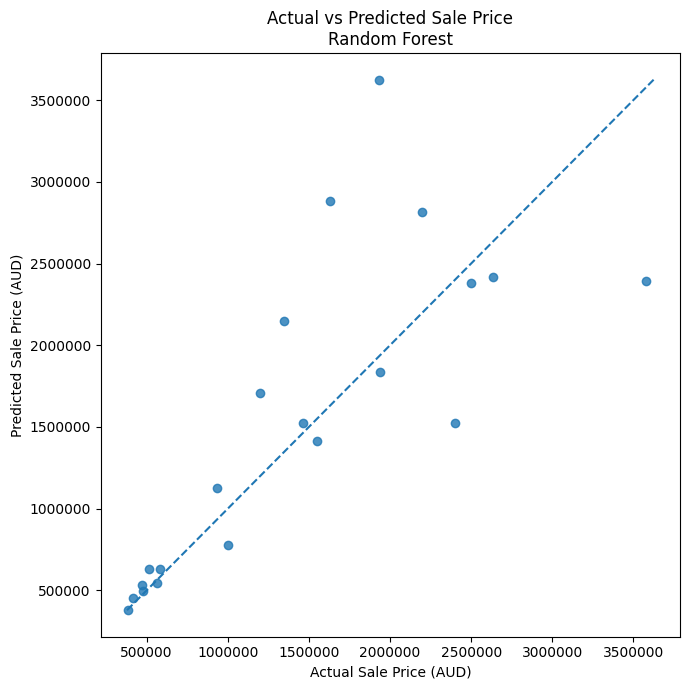

In [30]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.8
)

minimum = min(
    y_test.min(),
    best_predictions.min()
)

maximum = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title(
    f"Actual vs Predicted Sale Price\n{best_model_name}"
)

plt.xlabel("Actual Sale Price (AUD)")
plt.ylabel("Predicted Sale Price (AUD)")

plt.ticklabel_format(
    style="plain",
    axis="both"
)

plt.tight_layout()
plt.show()

In [31]:
error_analysis = X_test.copy()

error_analysis["Actual_Price"] = y_test.values

error_analysis["Predicted_Price"] = (
    best_predictions
)

error_analysis["Prediction_Error"] = (
    error_analysis["Actual_Price"] -
    error_analysis["Predicted_Price"]
)

error_analysis["Absolute_Error"] = (
    np.abs(
        error_analysis["Prediction_Error"]
    )
)

error_analysis["Percentage_Error"] = (
    error_analysis["Absolute_Error"] /
    error_analysis["Actual_Price"]
) * 100

error_analysis = error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
)

display(
    error_analysis.round(2)
)

,Suburb,Postcode,Bedrooms,Bathrooms,Parking,Property_Type,Sale_Year,Sale_Month,Total_Room_Feature,Amenity_Count,Actual_Price,Predicted_Price,Prediction_Error,Absolute_Error,Percentage_Error
29,Killara,2071,5,5,4,house,2012,11,10,14,1930000,3624934.63,-1694934.63,1694934.63,87.82
17,Killara,2071,4,3,2,house,2016,8,7,9,1630000,2883103.28,-1253103.28,1253103.28,76.88
43,Freshwater,2096,4,2,3,house,2017,5,6,9,3575000,2392681.43,1182318.57,1182318.57,33.07
25,Killara,2071,4,3,3,house,2014,3,7,10,2400000,1525856.63,874143.37,874143.37,36.42
55,Freshwater,2096,3,2,2,house,2019,6,5,7,1345000,2146230.47,-801230.47,801230.47,59.57
15,Killara,2071,2,1,1,house,2017,2,3,4,2200000,2816265.61,-616265.61,616265.61,28.01
52,Freshwater,2096,2,1,1,townhouse,2014,11,3,4,1200000,1708302.57,-508302.57,508302.57,42.36
37,Freshwater,2096,2,1,2,house,2009,9,3,5,1000000,777550.25,222449.75,222449.75,22.24
41,Freshwater,2096,4,3,2,house,2019,3,7,9,2637500,2415793.43,221706.57,221706.57,8.41
68,Freshwater,2096,3,2,1,house,2013,8,5,6,936000,1125099.89,-189099.89,189099.89,20.20


# Part 5 – Comparison with LLM and Human Estimates

To compare different approaches to property valuation, 10 properties are selected from the held-out test set.

For each property, three estimates are considered:

- the prediction generated by the selected machine learning model;
- an estimate generated by a Large Language Model using the same supplied property information; and
- my own human estimate based on the same information.

The LLM and human estimates are made without using the actual sale price. After all estimates are recorded, they are compared with the true sale prices using MAE and RMSE.

This comparison helps evaluate whether a trained data-driven model provides advantages over general reasoning and human judgement when all approaches have access to similar property information.

In [32]:
top_5_errors = error_analysis.head(5)

display(
    top_5_errors[
        [
            "Suburb",
            "Bedrooms",
            "Bathrooms",
            "Parking",
            "Property_Type",
            "Actual_Price",
            "Predicted_Price",
            "Absolute_Error",
            "Percentage_Error"
        ]
    ].round(2)
)

,Suburb,Bedrooms,Bathrooms,Parking,Property_Type,Actual_Price,Predicted_Price,Absolute_Error,Percentage_Error
29,Killara,5,5,4,house,1930000,3624934.63,1694934.63,87.82
17,Killara,4,3,2,house,1630000,2883103.28,1253103.28,76.88
43,Freshwater,4,2,3,house,3575000,2392681.43,1182318.57,33.07
25,Killara,4,3,3,house,2400000,1525856.63,874143.37,36.42
55,Freshwater,3,2,2,house,1345000,2146230.47,801230.47,59.57


In [33]:
top_5_errors = error_analysis.head(5)

display(
    top_5_errors[
        [
            "Suburb",
            "Bedrooms",
            "Bathrooms",
            "Parking",
            "Property_Type",
            "Actual_Price",
            "Predicted_Price",
            "Absolute_Error",
            "Percentage_Error"
        ]
    ].round(2)
)

,Suburb,Bedrooms,Bathrooms,Parking,Property_Type,Actual_Price,Predicted_Price,Absolute_Error,Percentage_Error
29,Killara,5,5,4,house,1930000,3624934.63,1694934.63,87.82
17,Killara,4,3,2,house,1630000,2883103.28,1253103.28,76.88
43,Freshwater,4,2,3,house,3575000,2392681.43,1182318.57,33.07
25,Killara,4,3,3,house,2400000,1525856.63,874143.37,36.42
55,Freshwater,3,2,2,house,1345000,2146230.47,801230.47,59.57


# Part 6 – Model Deployment and Web Application

After model evaluation was completed, the selected regression pipeline was retrained using the complete dataset and saved as `sydney_house_price_model.pkl`.

A simple interactive web application was developed using Streamlit. The application allows a user to provide:

- suburb;
- number of bedrooms;
- number of bathrooms;
- parking spaces;
- property type;
- sale year; and
- sale month.

The application automatically constructs the engineered features required by the trained model and passes the complete input to the saved machine learning pipeline. The resulting predicted sale price is displayed in Australian dollars.

The purpose of the application is to demonstrate how the trained machine learning model can be transformed from an experimental notebook into a simple decision-support tool.

In [38]:
comparison = X_test.copy()

comparison["Actual_Price"] = y_test.values
comparison["ML_Prediction"] = best_predictions

comparison = comparison.sample(
    n=10,
    random_state=10
).copy()

comparison = comparison[
    [
        "Suburb",
        "Postcode",
        "Bedrooms",
        "Bathrooms",
        "Parking",
        "Property_Type",
        "Sale_Year",
        "Actual_Price",
        "ML_Prediction"
    ]
]

comparison = comparison.reset_index(drop=True)

display(comparison)

,Suburb,Postcode,Bedrooms,Bathrooms,Parking,Property_Type,Sale_Year,Actual_Price,ML_Prediction
0,Eagle Vale,2558,3,1,2,house,2019,515000,6.321871e+05
1,Eagle Vale,2558,3,1,1,duplex/semi-detached,2015,414000,4.549529e+05
2,Freshwater,2096,3,2,1,house,2013,936000,1.125100e+06
3,Freshwater,2096,3,3,1,house,2017,2501000,2.383006e+06
4,Freshwater,2096,2,1,1,townhouse,2014,1200000,1.708303e+06
5,Freshwater,2096,3,2,2,house,2019,1345000,2.146230e+06
6,Killara,2071,5,5,4,house,2012,1930000,3.624935e+06
7,Killara,2071,4,3,3,house,2014,2400000,1.525857e+06
8,Eagle Vale,2558,3,2,2,house,2010,385000,3.786865e+05
9,Killara,2071,2,1,1,house,2017,2200000,2.816266e+06


In [40]:
llm_estimates = [
    000000,
    000000,
    000000,
    000000,
    000000,
    000000,
    000000,
    000000,
    000000,
    000000
]

human_estimates = [
    000000,
    000000,
    000000,
    000000,
    000000,
    000000,
    000000,
    000000,
    000000,
    000000
]

comparison["LLM_Estimate"] = llm_estimates
comparison["Human_Estimate"] = human_estimates

display(comparison)

,Suburb,Postcode,Bedrooms,Bathrooms,Parking,Property_Type,Sale_Year,Actual_Price,ML_Prediction,LLM_Estimate,Human_Estimate
0,Eagle Vale,2558,3,1,2,house,2019,515000,6.321871e+05,0,0
1,Eagle Vale,2558,3,1,1,duplex/semi-detached,2015,414000,4.549529e+05,0,0
2,Freshwater,2096,3,2,1,house,2013,936000,1.125100e+06,0,0
3,Freshwater,2096,3,3,1,house,2017,2501000,2.383006e+06,0,0
4,Freshwater,2096,2,1,1,townhouse,2014,1200000,1.708303e+06,0,0
5,Freshwater,2096,3,2,2,house,2019,1345000,2.146230e+06,0,0
6,Killara,2071,5,5,4,house,2012,1930000,3.624935e+06,0,0
7,Killara,2071,4,3,3,house,2014,2400000,1.525857e+06,0,0
8,Eagle Vale,2558,3,2,2,house,2010,385000,3.786865e+05,0,0
9,Killara,2071,2,1,1,house,2017,2200000,2.816266e+06,0,0


In [41]:
methods = [
    "ML_Prediction",
    "LLM_Estimate",
    "Human_Estimate"
]

comparison_results = []

for method in methods:

    mae = mean_absolute_error(
        comparison["Actual_Price"],
        comparison[method]
    )

    rmse = np.sqrt(
        mean_squared_error(
            comparison["Actual_Price"],
            comparison[method]
        )
    )

    comparison_results.append({
        "Method": method,
        "MAE": mae,
        "RMSE": rmse
    })

comparison_metrics = pd.DataFrame(
    comparison_results
)

display(comparison_metrics.round(2))

,Method,MAE,RMSE
0,ML_Prediction,496642.35,705846.03
1,LLM_Estimate,1382600.00,1590278.84
2,Human_Estimate,1382600.00,1590278.84


In [42]:
comparison["ML_Error"] = abs(
    comparison["Actual_Price"] -
    comparison["ML_Prediction"]
)

comparison["LLM_Error"] = abs(
    comparison["Actual_Price"] -
    comparison["LLM_Estimate"]
)

comparison["Human_Error"] = abs(
    comparison["Actual_Price"] -
    comparison["Human_Estimate"]
)

display(
    comparison.round(2)
)

,Suburb,Postcode,Bedrooms,Bathrooms,Parking,Property_Type,Sale_Year,Actual_Price,ML_Prediction,LLM_Estimate,Human_Estimate,ML_Error,LLM_Error,Human_Error
0,Eagle Vale,2558,3,1,2,house,2019,515000,632187.05,0,0,117187.05,515000,515000
1,Eagle Vale,2558,3,1,1,duplex/semi-detached,2015,414000,454952.88,0,0,40952.88,414000,414000
2,Freshwater,2096,3,2,1,house,2013,936000,1125099.89,0,0,189099.89,936000,936000
3,Freshwater,2096,3,3,1,house,2017,2501000,2383006.48,0,0,117993.52,2501000,2501000
4,Freshwater,2096,2,1,1,townhouse,2014,1200000,1708302.57,0,0,508302.57,1200000,1200000
5,Freshwater,2096,3,2,2,house,2019,1345000,2146230.47,0,0,801230.47,1345000,1345000
6,Killara,2071,5,5,4,house,2012,1930000,3624934.63,0,0,1694934.63,1930000,1930000
7,Killara,2071,4,3,3,house,2014,2400000,1525856.63,0,0,874143.37,2400000,2400000
8,Eagle Vale,2558,3,2,2,house,2010,385000,378686.50,0,0,6313.50,385000,385000
9,Killara,2071,2,1,1,house,2017,2200000,2816265.61,0,0,616265.61,2200000,2200000


In [43]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", models[best_model_name])
])

final_model.fit(
    X,
    y
)

print(
    "Final model trained:",
    best_model_name
)

Final model trained: Random Forest


In [44]:
joblib.dump(
    final_model,
    "sydney_house_price_model.pkl"
)

print(
    "Model saved as "
    "sydney_house_price_model.pkl"
)

Model saved as sydney_house_price_model.pkl


In [45]:
files.download(
    "sydney_house_price_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
cv_results_df.to_csv(
    "cross_validation_results.csv",
    index=False
)

test_results_df.to_csv(
    "test_results.csv",
    index=False
)

top_5_errors.to_csv(
    "top_5_prediction_errors.csv",
    index=False
)

print("Result files saved.")

Result files saved.


In [49]:
import os

print("Files currently available:")
for file in os.listdir():
    print(file)

Files currently available:
.config
cross_validation_results.csv
top_5_prediction_errors.csv
sydney_house_price_model.pkl
test_results.csv
Sydney_Housing_Data_8.1D.csv
sample_data


In [50]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 54.1 MB/s eta 0:00:00


In [51]:
import streamlit

print("Streamlit version:", streamlit.__version__)
print("Streamlit installed successfully.")

Streamlit version: 1.64.0
Streamlit installed successfully.


In [52]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

model = joblib.load("sydney_house_price_model.pkl")

st.set_page_config(
    page_title="Sydney Housing Price Predictor",
    page_icon="🏠",
    layout="centered"
)

st.title("Sydney Housing Price Prediction")
st.write(
    "Enter property details below to estimate the sale price "
    "using the trained machine learning model."
)

suburb = st.selectbox(
    "Suburb",
    ["Killara", "Freshwater", "Eagle Vale"]
)

postcode_map = {
    "Killara": "2071",
    "Freshwater": "2096",
    "Eagle Vale": "2558"
}

postcode = postcode_map[suburb]

bedrooms = st.number_input(
    "Bedrooms",
    min_value=1,
    max_value=10,
    value=3
)

bathrooms = st.number_input(
    "Bathrooms",
    min_value=1,
    max_value=10,
    value=2
)

parking = st.number_input(
    "Parking Spaces",
    min_value=0,
    max_value=10,
    value=1
)

property_type = st.selectbox(
    "Property Type",
    [
        "house",
        "townhouse",
        "villa",
        "duplex/semi-detached"
    ]
)

sale_year = st.number_input(
    "Sale Year",
    min_value=2000,
    max_value=2030,
    value=2018
)

sale_month = st.slider(
    "Sale Month",
    min_value=1,
    max_value=12,
    value=6
)

total_room_feature = bedrooms + bathrooms

amenity_count = bedrooms + bathrooms + parking

input_data = pd.DataFrame({
    "Suburb": [suburb],
    "Postcode": [postcode],
    "Bedrooms": [bedrooms],
    "Bathrooms": [bathrooms],
    "Parking": [parking],
    "Property_Type": [property_type],
    "Sale_Year": [sale_year],
    "Sale_Month": [sale_month],
    "Total_Room_Feature": [total_room_feature],
    "Amenity_Count": [amenity_count]
})

if st.button("Predict Sale Price"):

    prediction = model.predict(input_data)[0]

    st.success(
        f"Estimated Sale Price: ${prediction:,.0f}"
    )

    st.subheader("Property Summary")

    st.write("Suburb:", suburb)
    st.write("Postcode:", postcode)
    st.write("Bedrooms:", bedrooms)
    st.write("Bathrooms:", bathrooms)
    st.write("Parking:", parking)
    st.write("Property Type:", property_type)

st.caption(
    "Prediction is an estimate based on historical housing data "
    "and should not be treated as a professional property valuation."
)

Writing app.py


### Running the Application

The Streamlit application was developed and tested through Google Colab. The trained model file and `app.py` are kept together so that the application can load the complete preprocessing and regression pipeline.

The application is started using Streamlit on port 8501. Because Google Colab does not directly expose this local port to the public internet, a secure tunnel is used to access the application through a browser.

To use the application, the user selects the suburb and property characteristics, enters the sale year and month, and selects **Predict Sale Price**. The trained model then generates an estimated sale price.

The displayed value should be interpreted as an indicative machine learning estimate rather than a formal property valuation.

In [53]:
!ls -lh app.py sydney_house_price_model.pkl

-rw-r--r-- 1 root root 2.3K Sep 21 02:03 app.py
-rw-r--r-- 1 root root 1.3M Sep 21 01:56 sydney_house_price_model.pkl


In [54]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [55]:
import time
time.sleep(10)

print("Streamlit server started.")

Streamlit server started.


In [56]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 4s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [57]:
!wget -q -O - ipv4.icanhazip.com

34.139.135.95


In [ ]:
!lt --port 8501

your url is: https://funny-corners-enter.loca.lt


# Final Reflection

This project demonstrated the complete machine learning lifecycle, beginning with housing data preparation and exploratory analysis and progressing through feature engineering, model development, cross-validation, error analysis and deployment.

One of the main challenges was working with a relatively small dataset while representing three different housing markets. Model performance was also limited by the available property attributes. Important determinants of housing prices, including land size, exact location, condition and renovation quality, were unavailable.

The comparison of multiple regression algorithms demonstrated why model selection should be based on systematic validation rather than training performance alone. Error analysis was also valuable because it showed that overall accuracy metrics can hide substantial errors for individual properties.

From an ethical perspective, a housing prediction system can reflect biases already present in historical market data. Predictions may also be misleading if users interpret them as guaranteed market values. For this reason, the application clearly presents the output as an estimate and should be considered a decision-support tool rather than a replacement for professional valuation.

With more time, I would improve the project by collecting a larger and more recent dataset, adding land size, geographic coordinates, property condition and proximity to transport and schools, and performing more extensive hyperparameter optimisation.

## Generative AI Acknowledgement

Generative AI was used to assist with planning the notebook structure, troubleshooting code, and improving the clarity of written explanations. The generated suggestions were reviewed and adapted to the project, and the final analysis, model outputs and conclusions were checked against the results produced by the notebook.